In [2]:
!pip install opendatasets

In [4]:
import opendatasets as op
import os

if not os.path.exists("./covid19-radiography-database"):
  op.download("https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/")
else:
  print("Датасет уже загружен!")

Датасет уже загружен!


Импорт библиотек

In [56]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import keras
from keras.preprocessing.image import  load_img                                       # загрузка изображений
from keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import random                                                                         # генератор случайных чисел

import numpy as np                                                                    # библиотека линейной алгебры
import pandas as pd                                                                   # библиотека обработки табличных данных
import os                                                                             # библиотека работы с функциями операционной системы, в том числе с файлами
import albumentations as A                                                            # библиотека аугментации изображений (https://albumentations.ai/)

import matplotlib.pyplot as plt                                                       # библиотека для рисования графиков
%matplotlib inline

In [7]:
dataset_path = './covid19-radiography-database/COVID-19_Radiography_Dataset/Normal'
image_dir = 'images'
label_dir = 'masks'

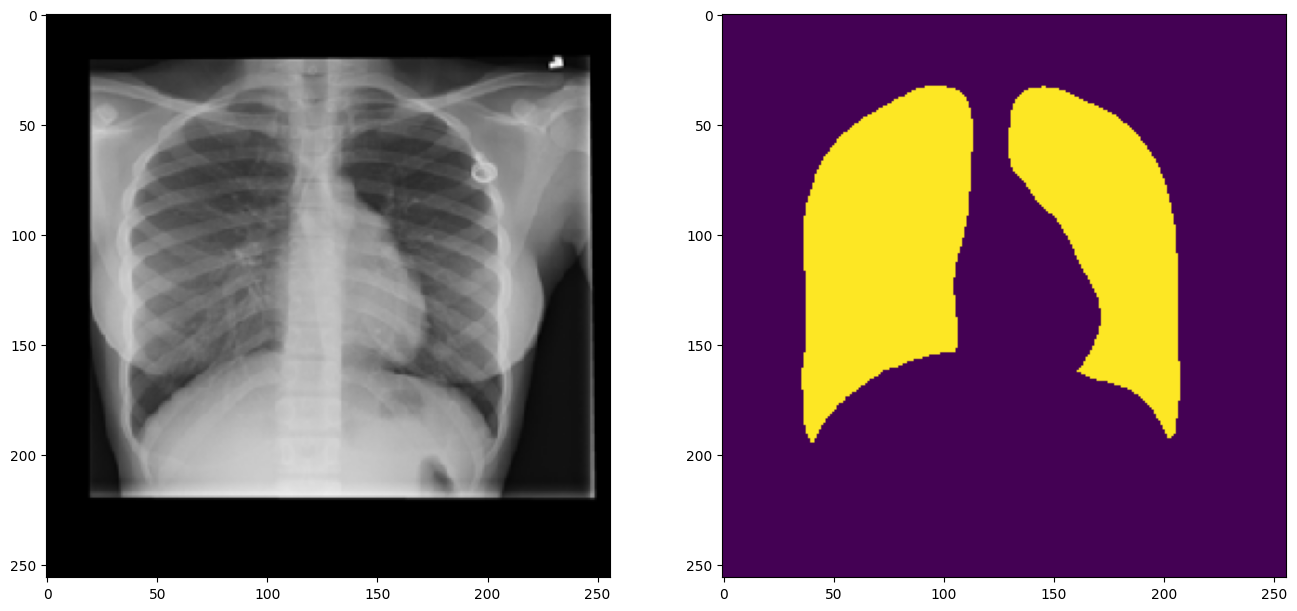

In [9]:
original_image = os.path.join(dataset_path, image_dir, 'Normal-1.png')       # путь до ориганального изображения
label_image_semantic = os.path.join(dataset_path, label_dir, 'Normal-1.png') # путь до маски

fig, axs = plt.subplots(1, 2, figsize=(16, 8))                          # задаем область для построения (канвас)

img = np.array(load_img(original_image, target_size=(256, 256), color_mode='rgb'))   # загружаем оригинальное изображение как RGB с 3 каналами
mask = np.array(load_img(label_image_semantic, target_size=(256, 256), color_mode='grayscale'))  # загружаем маску как "отеннки серого", т.е. в один канал

axs[0].imshow(img)  # отрисовываем оригинальное изображение
axs[0].grid(False)

axs[1].imshow(mask) # отрисовываем маску (одноканальное изображение, каждый класс отображается как отдельный цвет)
axs[1].grid(False)

In [47]:
input_img_path = sorted(
    [
        os.path.join(dataset_path, image_dir, fname)
        for fname in os.listdir(os.path.join(dataset_path, image_dir))
        if fname.endswith(".png")
    ]
)

target_img_path = sorted(
    [
        os.path.join(dataset_path, label_dir, fname)
        for fname in os.listdir(os.path.join(dataset_path, label_dir))
        if fname.endswith(".png")
    ]
)


NUM_CLASSES = 2
IMG_SIZE = (128, 128)

In [48]:
print("Количество изображений нормальных легких: ", len(input_img_path))
print("Количество масок нормальных легких: ", len(target_img_path))

Количество изображений нормальных легких:  10192
Количество масок нормальных легких:  10192


In [49]:
# Генератор для перебора данных (в виде массивов Numpy)
'''batch_size = 32
img_size = IMG_SIZE
num_classes = NUM_CLASSES
class datasetGenerator(keras.utils.Sequence):

    def __init__(self, batch_size, img_size, input_img_path, target_img_path = None, num_classes = NUM_CLASSES, validation = False):
        self.batch_size = batch_size
        self.img_size = img_size
        self.input_img_path = input_img_path
        self.target_img_path = target_img_path
        self.validation = validation


    def __len__(self):
        """Возвращает число мини-батчей обучающей выборки"""
        return len(self.target_img_path) // self.batch_size


    def __getitem__(self, idx):
        """Возвращает кортеж (input, target) соответствующий индексу пакета idx"""

        # Формируем пакеты из ссылок путем среза длинной в batch_size и возвращаем пакет по индексу
        batch_input_img_path = self.input_img_path[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_target_img_path = self.target_img_path[idx*self.batch_size:(idx+1)*self.batch_size]

        # Создадим массив numpy, заполненный нулями, для входных данных формы (BATCH_SIZE, IMAGE_HEIGHT, IMAGE_WIDTH, 3) и типа данных float32
        x = np.zeros((self.batch_size, *self.img_size, 3), dtype="float32")

        # Создадим массив numpy, заполненный нулями, для выходных данных формы (BATCH_SIZE, IMAGE_HEIGHT, IMAGE_WIDTH, 1) и типа данных uint8
        y = np.zeros((self.batch_size, *self.img_size, num_classes), dtype="uint8")

        # В цикле заполняем массивы с изображениями x и y
        # Перебираем пакеты из путей batch_input_img_path и batch_target_img_path к изображениям
        # zip возвращает для нескольких последовательностей список кортежей из элементов последовательностей с одинаковыми индексами
        for _, paths in enumerate(zip(batch_input_img_path, batch_target_img_path)):

            # Загружаем изображение и маску используя путь файловой системы
            img = np.array(load_img(paths[0], target_size=self.img_size, color_mode='rgb'))         # 3 канала для изображения
            mask = np.array(load_img(paths[1], target_size=self.img_size, color_mode='grayscale'))  # 1 канал для маски

            if self.validation == False:
                # Применяем аугментацию для проверочной выборки (p - вероятность применения, 0.5 - для каждого второго изображения)
                transform = A.Compose([ # определяем функцию аугментации
                                A.Flip(p=0.5), # Отражение изображения по горизонтали и вертикали
                                A.RandomRotate90(always_apply=False, p=0.5) # Случайный поворот на 90 градусов
                                 ])
                transformed = transform(image=img, mask=mask) # применяем функцию аугментации в изображению и маске
                img = transformed["image"]
                mask = transformed["mask"]

            x[_] = img / 255 # нормализуем изображение
            y[_] = to_categorical(mask, num_classes=num_classes) # преобразует маску из целых чисел в двоичную матрицу класса

        return x, y'''


In [63]:
# Генератор для перебора данных (в виде массивов Numpy)
batch_size = 32
img_size = IMG_SIZE
num_classes = NUM_CLASSES
class datasetGenerator(keras.utils.Sequence):
    def __init__(self, batch_size, img_size, input_img_path, target_img_path=None,
                 num_classes=NUM_CLASSES, validation=False):
        self.batch_size = batch_size
        self.img_size = img_size
        self.input_img_path = input_img_path
        self.target_img_path = target_img_path
        self.validation = validation
        self.num_classes = num_classes

    def __len__(self):
        return int(np.ceil(len(self.input_img_path) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_start = idx * self.batch_size
        batch_end = min((idx + 1) * self.batch_size, len(self.input_img_path))
        actual_batch_size = batch_end - batch_start

        batch_input_img_path = self.input_img_path[batch_start:batch_end]
        batch_target_img_path = self.target_img_path[batch_start:batch_end]

        x = np.zeros((actual_batch_size, *self.img_size, 3), dtype="float32")

        # Для глубокого супервизора нужно 4 выхода (одинаковые маски)
        y_main = np.zeros((actual_batch_size, *self.img_size, self.num_classes), dtype="float32")
        y1 = np.zeros((actual_batch_size, *self.img_size, self.num_classes), dtype="float32")
        y2 = np.zeros((actual_batch_size, *self.img_size, self.num_classes), dtype="float32")
        y3 = np.zeros((actual_batch_size, *self.img_size, self.num_classes), dtype="float32")

        for i, (img_path, mask_path) in enumerate(zip(batch_input_img_path, batch_target_img_path)):
            # Загружаем изображение
            img = np.array(load_img(img_path, target_size=self.img_size, color_mode='rgb'))

            # Загружаем маску
            mask = np.array(load_img(mask_path, target_size=self.img_size, color_mode='grayscale'))

            # Нормализуем маску
            mask = mask.astype(np.float32) / 255.0

            if not self.validation:
                # Аугментация
                transform = A.Compose([
                    A.HorizontalFlip(p=0.5),
                    A.VerticalFlip(p=0.5),
                    A.RandomRotate90(p=0.5),
                ])
                transformed = transform(image=img, mask=mask)
                img = transformed["image"]
                mask = transformed["mask"]

            x[i] = img / 255.0

            # Преобразуем маску в категориальный формат
            binary_mask = (mask > 0.5).astype(np.uint8)
            categorical_mask = to_categorical(binary_mask, num_classes=self.num_classes)

            # Для глубокого супервизора все выходы получают одинаковую маску
            # Но разные выходы могут работать с разными размерами (у вас есть UpSampling)
            # Здесь мы даем им все одинаковые маски исходного размера
            y_main[i] = categorical_mask
            y1[i] = categorical_mask
            y2[i] = categorical_mask
            y3[i] = categorical_mask

        # Возвращаем словарь для соответствия именам выходов модели
        return x, {
            'main_output': y_main,
            'output1': y1,
            'output2': y2,
            'output3': y3
        }

In [64]:
import random

seed = 1523
random.Random(seed).shuffle(input_img_path)
random.Random(seed).shuffle(target_img_path)

In [65]:
val_samples = round(len(input_img_path) * 0.2)

# Расщепим наш датасет  на обучающую и проверочные выборки
train_input_img_path = input_img_path[:-val_samples]
train_target_img_path = target_img_path[:-val_samples]
val_input_img_path = input_img_path[-val_samples:]
val_target_img_path = target_img_path[-val_samples:]

In [66]:
train_gen = datasetGenerator(batch_size, img_size, train_input_img_path, train_target_img_path, num_classes)

val_gen = datasetGenerator(batch_size, img_size, val_input_img_path, val_target_img_path, num_classes, validation = True)

**U-Net (оригинальная, 2015)**

Skip-connections: Прямые соединения между энкодером и декодером

Архитектура: Симметричная U-образная форма

**U-Net++ (2018)**

Вложенные декодеры: Несколько декодеров на разных уровнях

Плотные блоки: Каждый узел принимает входы от всех предыдущих узлов

**Архитектурные принципы U-Net++:**

1. Вложенная плотная архитектура (Nested Dense Architecture)

Вместо простых skip-connections как в обычной U-Net

Каждый узел получает входы от всех предыдущих узлов того же уровня

Формирует плотную сеть соединений между энкодером и декодером

2. Многоуровневые декодеры

Не один декодерный путь, а несколько параллельных

Каждый уровень декодера работает со своей степенью детализации

Мелкие уровни: детали, границы

Глубокие уровни: семантический контекст

**Глубокий супервизор (Deep Supervision) - ключевая особенность.**

*Принцип работы:*

Не один выход, а несколько выходов на разных уровнях декодера

**У нас будет реализовано 4 выхода:**

*output1 - самый ранний/мелкий уровень*

*output2 - средний уровень*

*output3 - поздний уровень*

*main_output - финальный/главный выход*

В данной работе соберем **U-Net++**

In [36]:
# Архитектура U-Net++
'''def conv_block(input_tensor, filters, kernel_size=3, dropout_rate=0.1):
    """Блок сверток с BatchNorm и Dropout"""
    x = Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate:
        x = Dropout(dropout_rate)(x)
    return x'''

In [67]:
def build_unet_plus_plus_corrected(input_size=(128, 128, 3), num_classes=2, filters=32):
    """
    Реализация U-Net++ с корректными размерами выходов
    """
    inputs = Input(input_size)

    # Энкодер
    x00 = conv_block(inputs, filters)  # Level 0, Node 0 - размер: 128x128

    # Downsample 1
    x10 = MaxPooling2D(pool_size=(2, 2))(x00)  # 64x64
    x10 = conv_block(x10, filters*2)

    # Узел X01 - размер: 128x128
    up_x10_to_x00 = UpSampling2D(size=(2, 2))(x10)  # 64x64 -> 128x128
    x01_input = Concatenate()([x00, up_x10_to_x00])
    x01 = conv_block(x01_input, filters)

    # Downsample 2
    x20 = MaxPooling2D(pool_size=(2, 2))(x10)  # 32x32
    x20 = conv_block(x20, filters*4)

    # Узел X11 - размер: 64x64
    up_x20_to_x10 = UpSampling2D(size=(2, 2))(x20)  # 32x32 -> 64x64
    x11_input = Concatenate()([x10, up_x20_to_x10])
    x11 = conv_block(x11_input, filters*2)

    # Узел X02 - размер: 128x128
    up_x11_to_x00 = UpSampling2D(size=(2, 2))(x11)  # 64x64 -> 128x128
    up_x20_to_x00 = UpSampling2D(size=(4, 4))(x20)  # 32x32 -> 128x128
    x02_input = Concatenate()([x00, up_x11_to_x00, up_x20_to_x00])
    x02 = conv_block(x02_input, filters)

    # Downsample 3
    x30 = MaxPooling2D(pool_size=(2, 2))(x20)  # 16x16
    x30 = conv_block(x30, filters*8)

    # Узел X21 - размер: 32x32
    up_x30_to_x20 = UpSampling2D(size=(2, 2))(x30)  # 16x16 -> 32x32
    x21_input = Concatenate()([x20, up_x30_to_x20])
    x21 = conv_block(x21_input, filters*4)

    # Узел X12 - размер: 64x64
    up_x21_to_x10 = UpSampling2D(size=(2, 2))(x21)  # 32x32 -> 64x64
    up_x30_to_x10 = UpSampling2D(size=(4, 4))(x30)  # 16x16 -> 64x64
    x12_input = Concatenate()([x10, up_x21_to_x10, up_x30_to_x10])
    x12 = conv_block(x12_input, filters*2)

    # Узел X03 - размер: 128x128
    up_x12_to_x00 = UpSampling2D(size=(2, 2))(x12)  # 64x64 -> 128x128
    up_x21_to_x00 = UpSampling2D(size=(4, 4))(x21)  # 32x32 -> 128x128
    up_x30_to_x00 = UpSampling2D(size=(8, 8))(x30)  # 16x16 -> 128x128
    x03_input = Concatenate()([x00, up_x12_to_x00, up_x21_to_x00, up_x30_to_x00])
    x03 = conv_block(x03_input, filters)

    # Bottleneck
    x40 = MaxPooling2D(pool_size=(2, 2))(x30)  # 8x8
    x40 = conv_block(x40, filters*16)

    # Декодер с глубоким супервизором
    # Уровень 4 - размер: 16x16
    up_x40_to_x30 = UpSampling2D(size=(2, 2))(x40)  # 8x8 -> 16x16
    x31_input = Concatenate()([x30, up_x40_to_x30])
    x31 = conv_block(x31_input, filters*8)

    # Уровень 3 - размер: 32x32
    up_x31_to_x20 = UpSampling2D(size=(2, 2))(x31)  # 16x16 -> 32x32
    x22_input = Concatenate()([x20, up_x31_to_x20])
    x22 = conv_block(x22_input, filters*4)

    # Уровень 3.1 - размер: 64x64
    up_x22_to_x10 = UpSampling2D(size=(2, 2))(x22)  # 32x32 -> 64x64
    up_x31_to_x10 = UpSampling2D(size=(4, 4))(x31)  # 16x16 -> 64x64
    x13_input = Concatenate()([x10, up_x22_to_x10, up_x31_to_x10])
    x13 = conv_block(x13_input, filters*2)

    # Уровень 2 (основной выход) - размер: 128x128
    up_x13_to_x00 = UpSampling2D(size=(2, 2))(x13)  # 64x64 -> 128x128
    up_x22_to_x00 = UpSampling2D(size=(4, 4))(x22)  # 32x32 -> 128x128
    up_x31_to_x00 = UpSampling2D(size=(8, 8))(x31)  # 16x16 -> 128x128
    x04_input = Concatenate()([x00, up_x13_to_x00, up_x22_to_x00, up_x31_to_x00])
    x04 = conv_block(x04_input, filters)

    # Выходы для глубокого супервизора
    # Все выходы должны иметь размер 128x128
    output1 = Conv2D(num_classes, 1, activation='softmax', name='output1')(x01)  # уже 128x128

    output2 = Conv2D(num_classes, 1, activation='softmax', name='output2')(x02)  # уже 128x128

    output3 = Conv2D(num_classes, 1, activation='softmax', name='output3')(x03)  # уже 128x128

    # Основной выход
    main_output = Conv2D(num_classes, 1, activation='softmax', name='main_output')(x04)

    model = Model(inputs=inputs, outputs=[main_output, output1, output2, output3])

    return model

In [69]:
# Создаем модель
model = build_unet_plus_plus_corrected(input_size=(*IMG_SIZE, 3), num_classes=NUM_CLASSES, filters=32)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_88[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_88       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_89 (Conv2D)  │ (None, 128, 128,  │      9,248 │ activation_88[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_89[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_89       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_44          │ (None, 128, 128,  │          0 │ activation_89[0]… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 64, 64,    │          0 │ dropout_44[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_14… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_90[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_90       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_90[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_91[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_91       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_45          │ (None, 64, 64,    │          0 │ activation_91[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 32, 32,    │          0 │ dropout_45[0][0]

 Total params: 9,410,472 (35.90 MB)

 Trainable params: 9,403,176 (35.87 MB)

 Non-trainable params: 7,296 (28.50 KB)

In [71]:
# Упрощенная функция потерь для глубокого супервизора
def combined_loss(y_true, y_pred):
    """Комбинированная потеря для глубокого супервизора"""
    # Categorical crossentropy
    ce_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

    # Dice loss
    y_true_f = tf.keras.backend.flatten(y_true[..., 1])  # канал для легких
    y_pred_f = tf.keras.backend.flatten(y_pred[..., 1])
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + 1) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + 1)
    dice_loss = 1 - dice

    # Общая потеря
    return ce_loss + dice_loss

# Упрощенная метрика Dice
def dice_metric(y_true, y_pred):
    y_true_f = tf.keras.backend.flatten(y_true[..., 1])
    y_pred_f = tf.keras.backend.flatten(y_pred[..., 1])
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + 1)

In [73]:
optimizer = Adam(learning_rate=1e-3)

# Для каждого выхода своя функция потерь (одинаковая)
losses = {
    'main_output': combined_loss,
    'output1': combined_loss,
    'output2': combined_loss,
    'output3': combined_loss
}

# Веса для разных выходов (больше вес для основного выхода)
loss_weights = {
    'main_output': 1.0,
    'output1': 0.5,
    'output2': 0.3,
    'output3': 0.2
}

# Метрики для каждого выхода
metrics_dict = {
    'main_output': ['accuracy', dice_metric],
    'output1': ['accuracy', dice_metric],
    'output2': ['accuracy', dice_metric],
    'output3': ['accuracy', dice_metric]
}

model.compile(
    optimizer=optimizer,
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics_dict
)

In [76]:
# CALLBACKS
callbacks = [
    EarlyStopping(
        monitor='val_main_output_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    ReduceLROnPlateau(
        monitor='val_main_output_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        'best_lung_segmentation_model.h5',
        monitor='val_main_output_dice_metric',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

In [77]:
# Обучение модели
EPOCHS = 40

#Начинаем обучение U-Net++ с глубоким супервизором
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - loss: 0.2112 - main_output_accuracy: 0.9893 - main_output_dice_metric: 0.9695 - main_output_loss: 0.0600 - output1_accuracy: 0.9592 - output1_dice_metric: 0.8931 - output1_loss: 0.2186 - output2_accuracy: 0.9827 - output2_dice_metric: 0.9522 - output2_loss: 0.0960 - output3_accuracy: 0.9879 - output3_dice_metric: 0.9673 - output3_loss: 0.0656
Epoch 1: val_main_output_dice_metric improved from -inf to 0.96627, saving model to best_lung_segmentation_model.h5


255/255 ━━━━━━━━━━━━━━━━━━━━ 170s 665ms/step - loss: 0.2112 - main_output_accuracy: 0.9893 - main_output_dice_metric: 0.9695 - main_output_loss: 0.0600 - output1_accuracy: 0.9592 - output1_dice_metric: 0.8931 - output1_loss: 0.2186 - output2_accuracy: 0.9827 - output2_dice_metric: 0.9522 - output2_loss: 0.0960 - output3_accuracy: 0.9879 - output3_dice_metric: 0.9673 - output3_loss: 0.0655 - val_loss: 0.2323 - val_main_output_accuracy: 0.9872 - val_main_output_dice_metric: 0.9663 - val_main_output_loss: 0.0686 - val_output1_accuracy: 0.9568 - val_output1_dice_metric: 0.8965 - val_output1_loss: 0.2220 - val_output2_accuracy: 0.9780 - val_output2_dice_metric: 0.9435 - val_output2_loss: 0.1152 - val_output3_accuracy: 0.9829 - val_output3_dice_metric: 0.9570 - val_output3_loss: 0.0904 - learning_rate: 0.0010
Epoch 2/40
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - loss: 0.1628 - main_output_accuracy: 0.9915 - main_output_dice_metric: 0.9777 - main_output_loss: 0.0449 - output1_accuracy: 0.96

255/255 ━━━━━━━━━━━━━━━━━━━━ 169s 661ms/step - loss: 0.1628 - main_output_accuracy: 0.9915 - main_output_dice_metric: 0.9777 - main_output_loss: 0.0449 - output1_accuracy: 0.9675 - output1_dice_metric: 0.9175 - output1_loss: 0.1727 - output2_accuracy: 0.9864 - output2_dice_metric: 0.9649 - output2_loss: 0.0718 - output3_accuracy: 0.9904 - output3_dice_metric: 0.9754 - output3_loss: 0.0499 - val_loss: 0.1374 - val_main_output_accuracy: 0.9930 - val_main_output_dice_metric: 0.9820 - val_main_output_loss: 0.0363 - val_output1_accuracy: 0.9716 - val_output1_dice_metric: 0.9307 - val_output1_loss: 0.1463 - val_output2_accuracy: 0.9885 - val_output2_dice_metric: 0.9709 - val_output2_loss: 0.0596 - val_output3_accuracy: 0.9900 - val_output3_dice_metric: 0.9762 - val_output3_loss: 0.0506 - learning_rate: 0.0010
Epoch 3/40
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - loss: 0.1420 - main_output_accuracy: 0.9925 - main_output_dice_metric: 0.9809 - main_output_loss: 0.0394 - output1_accuracy: 0.97

255/255 ━━━━━━━━━━━━━━━━━━━━ 173s 677ms/step - loss: 0.1420 - main_output_accuracy: 0.9925 - main_output_dice_metric: 0.9809 - main_output_loss: 0.0394 - output1_accuracy: 0.9717 - output1_dice_metric: 0.9283 - output1_loss: 0.1510 - output2_accuracy: 0.9884 - output2_dice_metric: 0.9706 - output2_loss: 0.0610 - output3_accuracy: 0.9914 - output3_dice_metric: 0.9784 - output3_loss: 0.0445 - val_loss: 0.1410 - val_main_output_accuracy: 0.9934 - val_main_output_dice_metric: 0.9833 - val_main_output_loss: 0.0349 - val_output1_accuracy: 0.9707 - val_output1_dice_metric: 0.9306 - val_output1_loss: 0.1513 - val_output2_accuracy: 0.9866 - val_output2_dice_metric: 0.9667 - val_output2_loss: 0.0726 - val_output3_accuracy: 0.9917 - val_output3_dice_metric: 0.9794 - val_output3_loss: 0.0435 - learning_rate: 0.0010
Epoch 4/40
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - loss: 0.1290 - main_output_accuracy: 0.9933 - main_output_dice_metric: 0.9831 - main_output_loss: 0.0342 - output1_accuracy: 0.97

255/255 ━━━━━━━━━━━━━━━━━━━━ 170s 665ms/step - loss: 0.1290 - main_output_accuracy: 0.9933 - main_output_dice_metric: 0.9832 - main_output_loss: 0.0342 - output1_accuracy: 0.9737 - output1_dice_metric: 0.9340 - output1_loss: 0.1398 - output2_accuracy: 0.9891 - output2_dice_metric: 0.9729 - output2_loss: 0.0557 - output3_accuracy: 0.9920 - output3_dice_metric: 0.9802 - output3_loss: 0.0405 - val_loss: 0.1329 - val_main_output_accuracy: 0.9939 - val_main_output_dice_metric: 0.9846 - val_main_output_loss: 0.0311 - val_output1_accuracy: 0.9696 - val_output1_dice_metric: 0.9307 - val_output1_loss: 0.1549 - val_output2_accuracy: 0.9893 - val_output2_dice_metric: 0.9735 - val_output2_loss: 0.0555 - val_output3_accuracy: 0.9925 - val_output3_dice_metric: 0.9819 - val_output3_loss: 0.0380 - learning_rate: 0.0010
Epoch 5/40
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - loss: 0.1244 - main_output_accuracy: 0.9935 - main_output_dice_metric: 0.9837 - main_output_loss: 0.0338 - output1_accuracy: 0.97

255/255 ━━━━━━━━━━━━━━━━━━━━ 170s 665ms/step - loss: 0.1243 - main_output_accuracy: 0.9935 - main_output_dice_metric: 0.9837 - main_output_loss: 0.0337 - output1_accuracy: 0.9749 - output1_dice_metric: 0.9375 - output1_loss: 0.1334 - output2_accuracy: 0.9896 - output2_dice_metric: 0.9744 - output2_loss: 0.0535 - output3_accuracy: 0.9923 - output3_dice_metric: 0.9812 - output3_loss: 0.0392 - val_loss: 0.1112 - val_main_output_accuracy: 0.9945 - val_main_output_dice_metric: 0.9863 - val_main_output_loss: 0.0285 - val_output1_accuracy: 0.9767 - val_output1_dice_metric: 0.9440 - val_output1_loss: 0.1227 - val_output2_accuracy: 0.9905 - val_output2_dice_metric: 0.9769 - val_output2_loss: 0.0483 - val_output3_accuracy: 0.9932 - val_output3_dice_metric: 0.9836 - val_output3_loss: 0.0346 - learning_rate: 0.0010
Epoch 6/40
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - loss: 0.1141 - main_output_accuracy: 0.9940 - main_output_dice_metric: 0.9851 - main_output_loss: 0.0306 - output1_accuracy: 0.97

KeyboardInterrupt: 

Прервали обучение на 8 эпохе, но лучшая модель сохранена

In [81]:
# 1. Загрузить модель
best_model = tf.keras.models.load_model('best_lung_segmentation_model.h5',
                                        custom_objects={'dice_metric': dice_metric,
                                                       'combined_loss': combined_loss})

# 2. Сохранить в новом формате
best_model.save('lung_segmentation_unet_plus_plus.keras')
print("Модель сохранена в формате .keras")

# 3. Протестировать на 3 батчах
dice_scores = []
accuracy_scores = []

for i in range(min(3, len(val_gen))):
    x_batch, y_batch = val_gen[i]
    results = best_model.evaluate(x_batch, y_batch, verbose=1)
    dice_scores.append(results[6])  # main_output_dice_metric
    accuracy_scores.append(results[5])  # main_output_accuracy

print(f"Средний Dice на 3 батчах: {np.mean(dice_scores):.4f} (±{np.std(dice_scores):.4f})")
print(f"Средняя Accuracy на 3 батчах: {np.mean(accuracy_scores):.4f}")

Модель сохранена в формате .keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.1028 - main_output_accuracy: 0.9948 - main_output_dice_metric: 0.9876 - main_output_loss: 0.0250 - output1_accuracy: 0.9775 - output1_dice_metric: 0.9498 - output1_loss: 0.1131 - output2_accuracy: 0.9903 - output2_dice_metric: 0.9780 - output2_loss: 0.0482 - output3_accuracy: 0.9928 - output3_dice_metric: 0.9841 - output3_loss: 0.0339
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 0.1003 - main_output_accuracy: 0.9951 - main_output_dice_metric: 0.9875 - main_output_loss: 0.0246 - output1_accuracy: 0.9783 - output1_dice_metric: 0.9466 - output1_loss: 0.1135 - output2_accuracy: 0.9915 - output2_dice_metric: 0.9788 - output2_loss: 0.0424 - output3_accuracy: 0.9938 - output3_dice_metric: 0.9846 - output3_loss: 0.0313
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.1192 - main_output_accuracy: 0.9936 - main_output_dice_metric: 0.9838 - main_output_loss: 0.0333 - output1_accuracy: 0.9760 - output1_dice_metric: 0

Визуализация 12 снимков в сетке:


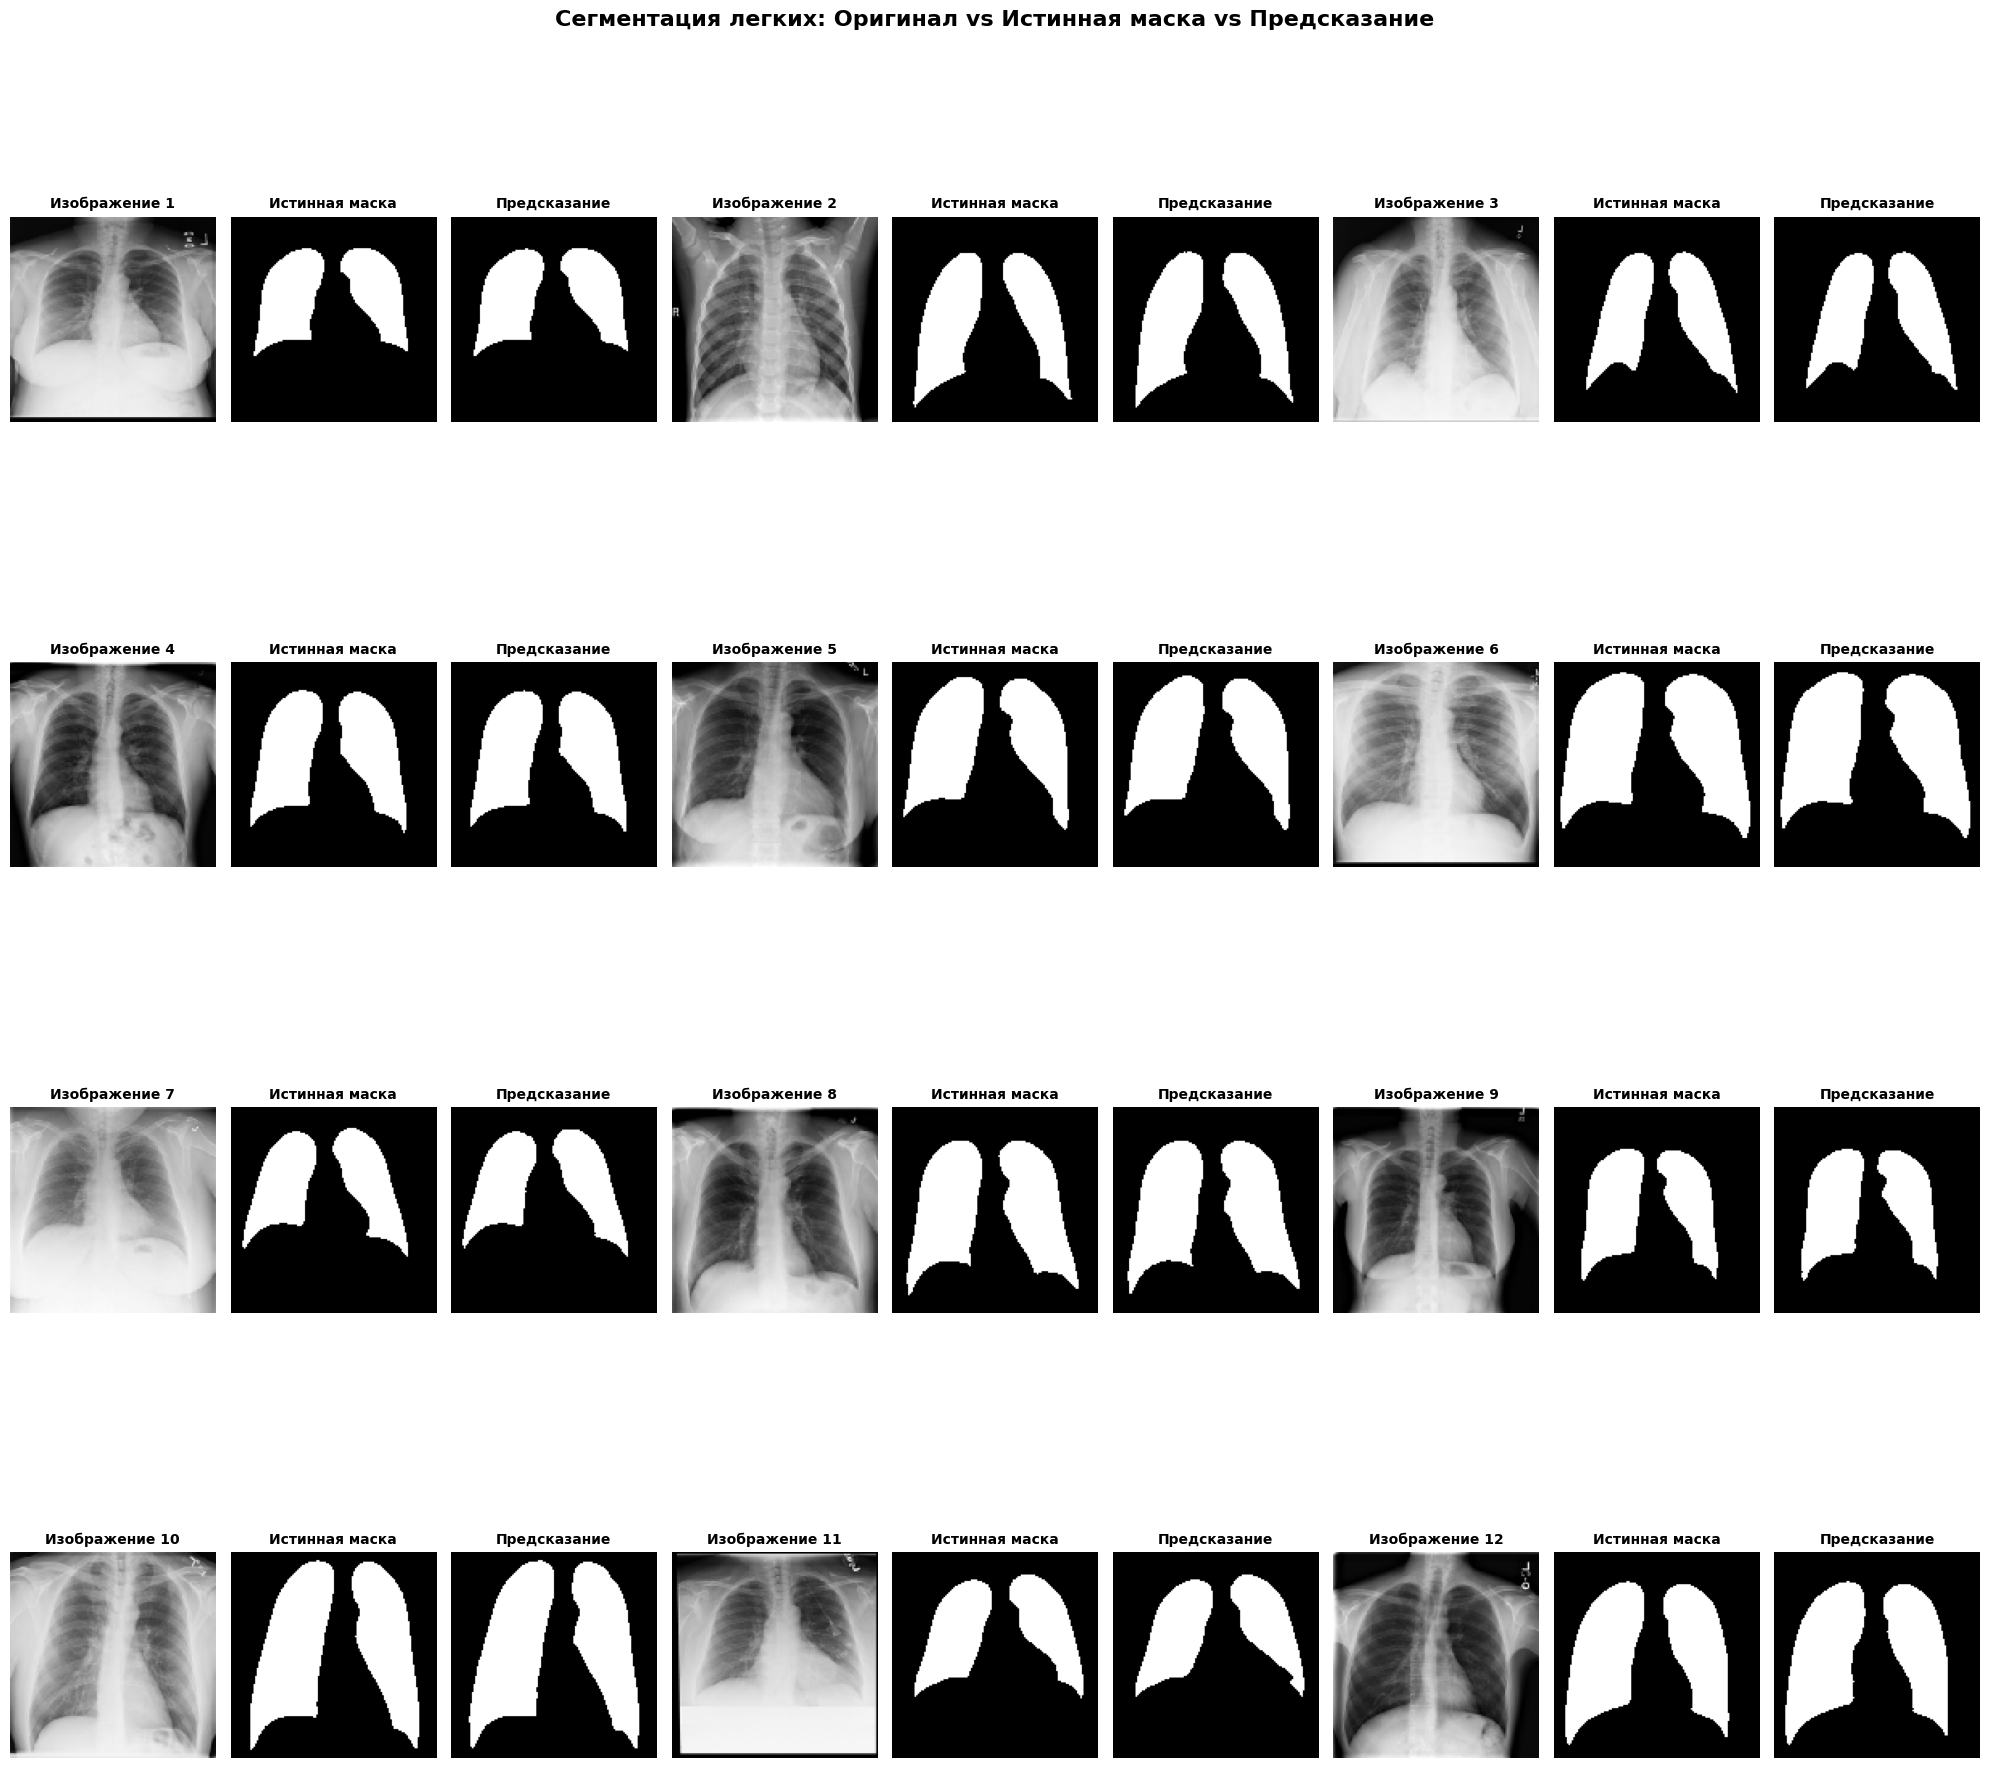

In [83]:
def visualize_predictions_grid(model, generator, num_samples=12, figsize=(20, 20)):
    """
    Визуализация в сетке: оригинал, маска, предсказание для 12 изображений
    """
    # Получаем батч данных
    x_batch, y_batch = generator[0]

    # Ограничиваем количество
    num_samples = min(num_samples, len(x_batch))

    # Создаем сетку 4 ряда × 3 колонки (12 изображений)
    rows = 4
    cols = 3
    fig, axes = plt.subplots(rows, cols * 3, figsize=(figsize[0], figsize[1]))

    for i in range(num_samples):
        row = i // cols
        col = (i % cols) * 3

        img = x_batch[i]
        true_mask = y_batch['main_output'][i][:, :, 1]  # Истинная маска

        # Предсказание
        predictions = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_mask = predictions[0][0][:, :, 1]  # Основной выход
        pred_binary = (pred_mask > 0.5).astype(np.float32)

        # Оригинальное изображение
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'Изображение {i+1}', fontsize=10, fontweight='bold')
        axes[row, col].axis('off')

        # Истинная маска
        axes[row, col + 1].imshow(true_mask, cmap='gray')
        axes[row, col + 1].set_title(f'Истинная маска', fontsize=10, fontweight='bold')
        axes[row, col + 1].axis('off')

        # Предсказанная маска
        axes[row, col + 2].imshow(pred_binary, cmap='gray')
        axes[row, col + 2].set_title(f'Предсказание', fontsize=10, fontweight='bold')
        axes[row, col + 2].axis('off')

    # Скрываем пустые оси
    for i in range(num_samples, rows * cols):
        row = i // cols
        col = (i % cols) * 3
        for j in range(3):
            axes[row, col + j].axis('off')

    plt.suptitle('Сегментация легких: Оригинал vs Истинная маска vs Предсказание',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Использование
print("Визуализация 12 снимков в сетке:")
visualize_predictions_grid(best_model, val_gen, num_samples=12)